<a href="https://colab.research.google.com/github/priyalimbu246/assignments/blob/main/ML_Project_Training_HOMO_LUMO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CHEM 4930/5610 — Final Project
## GNN for HOMO-LUMO Gap Prediction using QM9 Dataset
**Dr. Omar Valsson | Spring 2026**

This notebook trains Graph Neural Network models (GCN and GIN) to predict the
**HOMO-LUMO gap** (property index `gap`, column `4` in QM9 properties, units: Hartree)
from the QM9 dataset of ~134k organic molecules.


In [1]:
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install rdkit torch_geometric


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.8 MB/s eta 0:00:00


## 1. Imports

In [2]:
# Standard libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math, os, random

# RDKit
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors

# PyTorch & PyG
import torch
import torch.nn.functional as Fun
from torch.nn import Linear, Sequential, BatchNorm1d, ReLU, Dropout
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GINConv, global_mean_pool, global_add_pool

# Sklearn metrics
from sklearn.metrics import mean_absolute_error, r2_score

# Progress bar
from tqdm.auto import tqdm
tqdm.pandas()

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


## 2. Download QM9 Dataset

In [3]:
%%bash
# Download QM9 SDF and CSV from figshare / public mirror
# SDF contains all molecules; CSV contains all 19 properties

BASE_URL="https://deepchemdata.s3-us-west-1.amazonaws.com/datasets"

# Download the CSV with properties
if [ ! -f qm9.csv ]; then
    wget -q "${BASE_URL}/qm9.csv" -O qm9.csv
    echo "Downloaded qm9.csv"
else
    echo "qm9.csv already exists"
fi

wc -l qm9.csv
head -2 qm9.csv


Downloaded qm9.csv
133886 qm9.csv
mol_id,smiles,A,B,C,mu,alpha,homo,lumo,gap,r2,zpve,u0,u298,h298,g298,cv,u0_atom,u298_atom,h298_atom,g298_atom
gdb_1,C,157.7118,157.70997,157.70699,0,13.21,-0.3877,0.1171,0.5048,35.3641,0.044749,-40.47893,-40.476062,-40.475117,-40.498597,6.469,-395.999594594,-398.643290011,-401.014646522,-372.471772148


## 3. Load Properties CSV

The QM9 CSV contains 19 molecular properties. We target:
- **Column `gap`** — HOMO-LUMO gap (eV), index 4 among the quantum properties.

QM9 property columns (from the original paper):
`mu, alpha, homo, lumo, gap, r2, zpve, u0, u298, h298, g298, cv, u0_atom, u298_atom, h298_atom, g298_atom, A, B, C`


In [4]:
df = pd.read_csv("qm9.csv")
print(df.shape)
print(df.columns.tolist())
df.head()


(133885, 21)
['mol_id', 'smiles', 'A', 'B', 'C', 'mu', 'alpha', 'homo', 'lumo', 'gap', 'r2', 'zpve', 'u0', 'u298', 'h298', 'g298', 'cv', 'u0_atom', 'u298_atom', 'h298_atom', 'g298_atom']


,mol_id,smiles,A,B,C,mu,alpha,homo,lumo,gap,...,zpve,u0,u298,h298,g298,cv,u0_atom,u298_atom,h298_atom,g298_atom
0,gdb_1,C,157.71180,157.709970,157.706990,0.0000,13.21,-0.3877,0.1171,0.5048,...,0.044749,-40.478930,-40.476062,-40.475117,-40.498597,6.469,-395.999595,-398.643290,-401.014647,-372.471772
1,gdb_2,N,293.60975,293.541110,191.393970,1.6256,9.46,-0.2570,0.0829,0.3399,...,0.034358,-56.525887,-56.523026,-56.522082,-56.544961,6.316,-276.861363,-278.620271,-280.399259,-259.338802
2,gdb_3,O,799.58812,437.903860,282.945450,1.8511,6.31,-0.2928,0.0687,0.3615,...,0.021375,-76.404702,-76.401867,-76.400922,-76.422349,6.002,-213.087624,-213.974294,-215.159658,-201.407171
3,gdb_4,C#C,0.00000,35.610036,35.610036,0.0000,16.28,-0.2845,0.0506,0.3351,...,0.026841,-77.308427,-77.305527,-77.304583,-77.327429,8.574,-385.501997,-387.237686,-389.016047,-365.800724
4,gdb_5,C#N,0.00000,44.593883,44.593883,2.8937,12.99,-0.3604,0.0191,0.3796,...,0.016601,-93.411888,-93.409370,-93.408425,-93.431246,6.278,-301.820534,-302.906752,-304.091489,-288.720028


Target: gap
Stats:
count    133885.000000
mean          0.251100
std           0.047519
min           0.024600
25%           0.216300
50%           0.249400
75%           0.288200
max           0.622100
Name: gap, dtype: float64


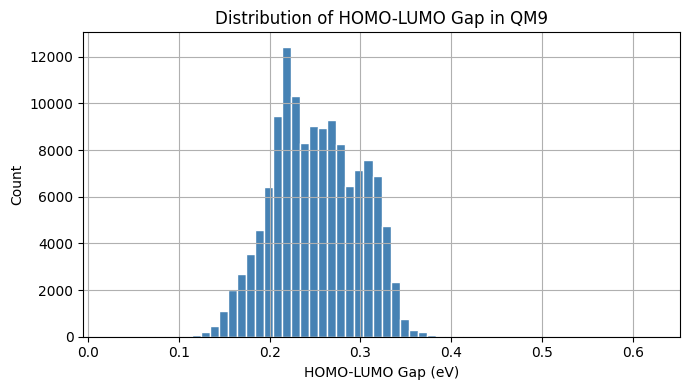

In [5]:
# Target property: HOMO-LUMO gap in eV
TARGET = "gap"
print(f"Target: {TARGET}")
print(f"Stats:\n{df[TARGET].describe()}")

plt.figure(figsize=(7,4))
df[TARGET].hist(bins=60, color='steelblue', edgecolor='white')
plt.xlabel("HOMO-LUMO Gap (eV)")
plt.ylabel("Count")
plt.title("Distribution of HOMO-LUMO Gap in QM9")
plt.tight_layout()
plt.show()


## 4. Molecule-to-Graph Conversion

Each atom becomes a **node** with one-hot encoded features.  
Each bond becomes two directed **edges** (undirected graph) with bond features.

### Node features
- Atomic number (one-hot, elements H,C,N,O,F — HCONF only in QM9)
- Degree
- Formal charge
- Chiral tag
- Hybridization (SP, SP2, SP3)
- Is aromatic
- Number of hydrogens

### Edge features
- Bond type (single, double, triple, aromatic)
- Stereo
- Is conjugated
- Is in ring


In [6]:
ATOM_FEATURES = {
    "atomic_num":    [1, 6, 7, 8, 9],          # H, C, N, O, F (QM9 only)
    "degree":        [0, 1, 2, 3, 4, 5],
    "formal_charge": [-1, 0, 1],
    "chiral_tag":    [0, 1, 2, 3],
    "hybridization": [
        Chem.rdchem.HybridizationType.S,
        Chem.rdchem.HybridizationType.SP,
        Chem.rdchem.HybridizationType.SP2,
        Chem.rdchem.HybridizationType.SP3,
        Chem.rdchem.HybridizationType.SP3D,
        Chem.rdchem.HybridizationType.SP3D2,
    ],
    "num_hs": [0, 1, 2, 3, 4],
}

BOND_FEATURES = {
    "bond_type": [
        Chem.rdchem.BondType.SINGLE,
        Chem.rdchem.BondType.DOUBLE,
        Chem.rdchem.BondType.TRIPLE,
        Chem.rdchem.BondType.AROMATIC,
    ],
    "stereo": [0, 1, 2, 3, 4, 5],
}


def one_hot(value, choices):
    """One-hot encode; unknown value → all-zeros vector with extra 'other' slot."""
    encoding = [0] * (len(choices) + 1)
    idx = choices.index(value) if value in choices else len(choices)
    encoding[idx] = 1
    return encoding


def atom_features(atom) -> list:
    feats = []
    feats += one_hot(atom.GetAtomicNum(),        ATOM_FEATURES["atomic_num"])
    feats += one_hot(atom.GetDegree(),           ATOM_FEATURES["degree"])
    feats += one_hot(atom.GetFormalCharge(),     ATOM_FEATURES["formal_charge"])
    feats += one_hot(int(atom.GetChiralTag()),   ATOM_FEATURES["chiral_tag"])
    feats += one_hot(atom.GetHybridization(),    ATOM_FEATURES["hybridization"])
    feats += one_hot(atom.GetTotalNumHs(),       ATOM_FEATURES["num_hs"])
    feats.append(int(atom.GetIsAromatic()))
    return feats


def bond_features(bond) -> list:
    feats = []
    feats += one_hot(bond.GetBondType(),    BOND_FEATURES["bond_type"])
    feats += one_hot(int(bond.GetStereo()), BOND_FEATURES["stereo"])
    feats.append(int(bond.GetIsConjugated()))
    feats.append(int(bond.IsInRing()))
    return feats


def mol_to_graph(mol, y=None):
    """Convert an RDKit molecule to a PyG Data object."""
    if mol is None:
        return None

    # Node features
    x = torch.tensor([atom_features(a) for a in mol.GetAtoms()], dtype=torch.float)

    # Edge features (undirected → two directed edges per bond)
    edge_index, edge_attr = [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        bf = bond_features(bond)
        edge_index += [[i, j], [j, i]]
        edge_attr  += [bf, bf]

    if len(edge_index) == 0:
        edge_index = torch.zeros((2, 0), dtype=torch.long)
        edge_attr  = torch.zeros((0, 14), dtype=torch.float)
    else:
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_attr  = torch.tensor(edge_attr,  dtype=torch.float)

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    if y is not None:
        data.y = torch.tensor([y], dtype=torch.float)
    return data


def smi_to_graph(smi, y=None):
    mol = Chem.MolFromSmiles(smi)
    return mol_to_graph(mol, y)


# Quick sanity check
g = smi_to_graph("CCO", y=0.5)
print("Node features:", g.x.shape)
print("Edge index:   ", g.edge_index.shape)
print("Edge attr:    ", g.edge_attr.shape)


Node features: torch.Size([3, 36])
Edge index:    torch.Size([2, 4])
Edge attr:     torch.Size([4, 14])


## 5. Build Graph Dataset from QM9

In [7]:
# For faster initial testing, use a subset.
# Set SUBSET = None to use the full dataset (~134k molecules).
SUBSET = None  # e.g. 20000 for quick testing

if SUBSET:
    df_use = df.sample(n=SUBSET, random_state=SEED).reset_index(drop=True)
    print(f"Using subset of {SUBSET} molecules")
else:
    df_use = df.reset_index(drop=True)
    print(f"Using full dataset: {len(df_use)} molecules")

mol_graphs = []
skipped = 0

for i, row in tqdm(df_use.iterrows(), total=len(df_use), desc="Building graphs"):
    smi = row["smiles"]
    y_val = row[TARGET]
    if pd.isna(y_val):
        skipped += 1
        continue
    g = smi_to_graph(smi, y=float(y_val))
    if g is not None:
        mol_graphs.append(g)
    else:
        skipped += 1

print(f"\nGraphs built: {len(mol_graphs)}  |  Skipped: {skipped}")
print(f"Node feature dim : {mol_graphs[0].num_features}")
print(f"Edge feature dim : {mol_graphs[0].num_edge_features}")


Using full dataset: 133885 molecules


Building graphs:   0%|          | 0/133885 [00:00<?, ?it/s]


Graphs built: 133885  |  Skipped: 0
Node feature dim : 36
Edge feature dim : 14


In [8]:
# Verify all graphs have consistent feature dimensions
node_dim = mol_graphs[0].num_features
edge_dim = mol_graphs[0].num_edge_features
bad = [i for i, g in enumerate(mol_graphs)
       if g.x.shape[1] != node_dim or g.edge_attr.shape[1] != edge_dim]
print(f"Graphs with inconsistent features: {len(bad)}")
for i in sorted(bad, reverse=True):
    del mol_graphs[i]
print(f"Graphs after cleanup: {len(mol_graphs)}")


Graphs with inconsistent features: 0
Graphs after cleanup: 133885


In [ ]:
print(f"Node feature dim : {mol_graphs[0].num_features}")

## 6. Train / Validation / Test Split + DataLoaders

In [9]:
random.shuffle(mol_graphs)

n = len(mol_graphs)
train_end = int(n * 0.80)
val_end   = int(n * 0.90)

train_set = mol_graphs[:train_end]
val_set   = mol_graphs[train_end:val_end]
test_set  = mol_graphs[val_end:]

BATCH_SIZE = 64

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train:      {len(train_set):>7,} molecules  ({len(train_loader):>4} batches)")
print(f"Validation: {len(val_set):>7,} molecules  ({len(val_loader):>4} batches)")
print(f"Test:       {len(test_set):>7,} molecules  ({len(test_loader):>4} batches)")


Train:      107,108 molecules  (1674 batches)
Validation:  13,388 molecules  ( 210 batches)
Test:        13,389 molecules  ( 210 batches)


## 7. GNN Model Architectures

### Model A — GCN (Graph Convolutional Network)
Uses `GCNConv` layers. Simple and fast.

### Model B — GIN (Graph Isomorphism Network)
Uses `GINConv` layers with MLP sub-networks and batch normalisation.
Generally more expressive than GCN.


In [10]:
class GCN(torch.nn.Module):
    """Graph Convolutional Network for regression."""

    def __init__(self, dim_input, dim_hidden=128, dropout=0.3):
        super().__init__()
        self.conv1 = GCNConv(dim_input,  dim_hidden)
        self.conv2 = GCNConv(dim_hidden, dim_hidden)
        self.conv3 = GCNConv(dim_hidden, dim_hidden)
        self.bn1   = BatchNorm1d(dim_hidden)
        self.bn2   = BatchNorm1d(dim_hidden)
        self.bn3   = BatchNorm1d(dim_hidden)
        self.lin1  = Linear(dim_hidden, dim_hidden // 2)
        self.lin2  = Linear(dim_hidden // 2, 1)
        self.drop  = Dropout(p=dropout)

    def forward(self, data):
        x, e, batch = data.x, data.edge_index, data.batch
        x = self.bn1(self.conv1(x, e).relu())
        x = self.bn2(self.conv2(x, e).relu())
        x = self.bn3(self.conv3(x, e).relu())
        x = global_mean_pool(x, batch)
        x = self.drop(x)
        x = self.lin1(x).relu()
        x = self.drop(x)
        return self.lin2(x)


class GIN(torch.nn.Module):
    """Graph Isomorphism Network for regression."""

    def _mlp(self, in_dim, out_dim):
        return Sequential(
            Linear(in_dim, out_dim), BatchNorm1d(out_dim), ReLU(),
            Linear(out_dim, out_dim), ReLU()
        )

    def __init__(self, dim_input, dim_hidden=128, dropout=0.3):
        super().__init__()
        self.conv1 = GINConv(self._mlp(dim_input,  dim_hidden))
        self.conv2 = GINConv(self._mlp(dim_hidden, dim_hidden))
        self.conv3 = GINConv(self._mlp(dim_hidden, dim_hidden))
        self.conv4 = GINConv(self._mlp(dim_hidden, dim_hidden))
        self.lin1  = Linear(dim_hidden, dim_hidden)
        self.lin2  = Linear(dim_hidden, dim_hidden // 2)
        self.lin3  = Linear(dim_hidden // 2, 1)
        self.drop  = Dropout(p=dropout)

    def forward(self, data):
        x, e, batch = data.x, data.edge_index, data.batch
        x = self.conv1(x, e).relu()
        x = self.conv2(x, e).relu()
        x = self.conv3(x, e).relu()
        x = self.conv4(x, e)
        x = global_add_pool(x, batch)
        x = self.lin1(x).relu()
        x = self.drop(x)
        x = self.lin2(x).relu()
        x = self.drop(x)
        return self.lin3(x)


## 8. Training Utilities

In [14]:
def run_epoch(loader, model, loss_fn, optimizer=None):
    """One training or validation epoch. Pass optimizer=None for eval mode."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total = 0.0
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for batch in loader:
            batch = batch.to(device)
            batch.x = batch.x.float()
            pred = model(batch)
            target = batch.y.view(-1, 1)
            loss = loss_fn(pred, target)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total += loss.item() / len(loader)
    return total


def train_model(model, train_loader, val_loader,
                epochs=200, lr=1e-3, save_path="best_model.pt",
                scheduler_patience=20):
    """Full training loop with early-stop saving and LR scheduler."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=scheduler_patience, factor=0.5)
    loss_fn   = torch.nn.MSELoss()

    train_losses, val_losses = [], []
    best_val = math.inf

    for epoch in range(1, epochs + 1):
        tr = run_epoch(train_loader, model, loss_fn, optimizer)
        vl = run_epoch(val_loader,   model, loss_fn)
        scheduler.step(vl)
        train_losses.append(tr)
        val_losses.append(vl)
        if vl < best_val:
            best_val = vl
            torch.save(model.state_dict(), save_path)
        if epoch % 20 == 0 or epoch == 1:
            print(f"Epoch {epoch:>4}/{epochs} | "
                  f"Train MSE: {tr:.5f} | Val MSE: {vl:.5f} | "
                  f"LR: {optimizer.param_groups[0]['lr']:.2e}")

    print(f"\nBest validation MSE: {best_val:.5f}  (saved \u2192 {save_path})")
    return train_losses, val_losses


def plot_loss_curves(train_loss, val_loss, title="Training Curve"):
    plt.figure(figsize=(8, 4))
    plt.plot(train_loss, label="Train MSE")
    plt.plot(val_loss,   label="Validation MSE")
    plt.yscale("log")
    plt.xlabel("Epoch"); plt.ylabel("MSE Loss (log scale)")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()


@torch.no_grad()
def evaluate_loader(loader, model):
    """Return numpy arrays of predictions and true values."""
    model.eval()
    preds, trues = [], []
    for batch in loader:
        batch = batch.to(device)
        batch.x = batch.x.float()
        out = model(batch).cpu().numpy().flatten()
        y   = batch.y.cpu().numpy().flatten()
        preds.extend(out); trues.extend(y)
    return np.array(preds), np.array(trues)


def plot_predictions(model, loaders_dict):
    """Scatter plot + residual plot for multiple data splits."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = {"Train": "steelblue", "Validation": "orange", "Test": "green"}

    all_true = []
    for split_name, loader in loaders_dict.items():
        preds, trues = evaluate_loader(loader, model)
        all_true.extend(trues)
        mae = mean_absolute_error(trues, preds)
        r2  = r2_score(trues, preds)
        lbl = f"{split_name} (MAE={mae:.3f}, R\u00b2={r2:.3f})"
        axes[0].scatter(preds, trues, alpha=0.3, s=5, label=lbl, color=colors[split_name])
        axes[1].scatter(preds, trues - preds, alpha=0.3, s=5, color=colors[split_name])

    diag = np.array([min(all_true), max(all_true)])
    axes[0].plot(diag, diag, 'r--', lw=1.5)
    axes[0].set_xlabel("Predicted HOMO-LUMO Gap (eV)")
    axes[0].set_ylabel("Actual HOMO-LUMO Gap (eV)")
    axes[0].set_title("Predicted vs. Actual"); axes[0].legend(fontsize=8)

    axes[1].axhline(0, color='black', lw=1)
    axes[1].set_xlabel("Predicted HOMO-LUMO Gap (eV)")
    axes[1].set_ylabel("Residual (Actual − Predicted)")
    axes[1].set_title("Residual Plot")

    plt.tight_layout(); plt.show()


def print_metrics(model, loaders_dict):
    print(f"{'Split':<12} {'MAE (eV)':>10} {'RMSE (eV)':>11} {'R\u00b2':>8}")
    print("-" * 44)
    for name, loader in loaders_dict.items():
        p, t = evaluate_loader(loader, model)
        mae  = mean_absolute_error(t, p)
        rmse = np.sqrt(np.mean((t - p)**2))
        r2   = r2_score(t, p)
        print(f"{name:<12} {mae:>10.4f} {rmse:>11.4f} {r2:>8.4f}")

## 9. Train GCN Model

In [12]:
DIM_INPUT  = mol_graphs[0].num_features

model_gcn = GCN(dim_input=DIM_INPUT, dim_hidden=128, dropout=0.3).to(device)
print(model_gcn)
total_params = sum(p.numel() for p in model_gcn.parameters())
print(f"\nTotal parameters: {total_params:,}")


GCN(
  (conv1): GCNConv(36, 128)
  (conv2): GCNConv(128, 128)
  (conv3): GCNConv(128, 128)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (lin1): Linear(in_features=128, out_features=64, bias=True)
  (lin2): Linear(in_features=64, out_features=1, bias=True)
  (drop): Dropout(p=0.3, inplace=False)
)

Total parameters: 46,849


In [15]:
gcn_train_loss, gcn_val_loss = train_model(
    model_gcn, train_loader, val_loader,
    epochs=300, lr=1e-3,
    save_path="best_gcn.pt"
)


Epoch    1/300 | Train MSE: 0.00248 | Val MSE: 0.00033 | LR: 1.00e-03
Epoch   20/300 | Train MSE: 0.00020 | Val MSE: 0.00016 | LR: 1.00e-03
Epoch   40/300 | Train MSE: 0.00018 | Val MSE: 0.00014 | LR: 1.00e-03
Epoch   60/300 | Train MSE: 0.00017 | Val MSE: 0.00012 | LR: 1.00e-03
Epoch   80/300 | Train MSE: 0.00015 | Val MSE: 0.00011 | LR: 5.00e-04
Epoch  100/300 | Train MSE: 0.00014 | Val MSE: 0.00010 | LR: 5.00e-04
Epoch  120/300 | Train MSE: 0.00014 | Val MSE: 0.00011 | LR: 5.00e-04
Epoch  140/300 | Train MSE: 0.00013 | Val MSE: 0.00010 | LR: 2.50e-04
Epoch  160/300 | Train MSE: 0.00013 | Val MSE: 0.00009 | LR: 2.50e-04
Epoch  180/300 | Train MSE: 0.00013 | Val MSE: 0.00010 | LR: 1.25e-04
Epoch  200/300 | Train MSE: 0.00013 | Val MSE: 0.00009 | LR: 1.25e-04
Epoch  220/300 | Train MSE: 0.00013 | Val MSE: 0.00009 | LR: 6.25e-05
Epoch  240/300 | Train MSE: 0.00012 | Val MSE: 0.00009 | LR: 6.25e-05
Epoch  260/300 | Train MSE: 0.00012 | Val MSE: 0.00009 | LR: 6.25e-05
Epoch  280/300 | Tra

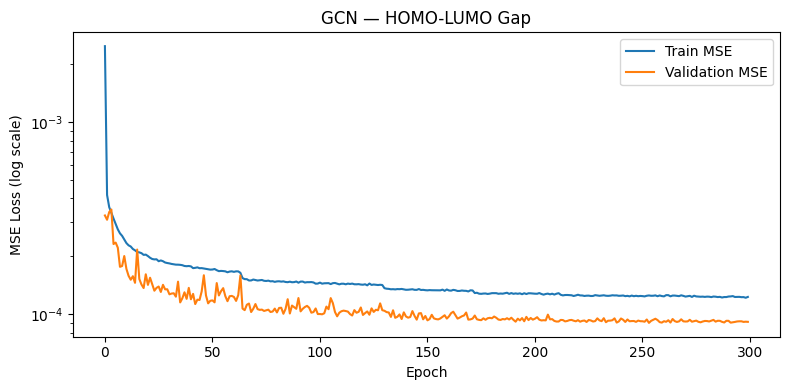

In [16]:
plot_loss_curves(gcn_train_loss, gcn_val_loss, title="GCN — HOMO-LUMO Gap")


Split          MAE (eV)   RMSE (eV)       R²
--------------------------------------------
Train            0.0057      0.0081   0.9711
Validation       0.0061      0.0095   0.9599
Test             0.0061      0.0091   0.9630


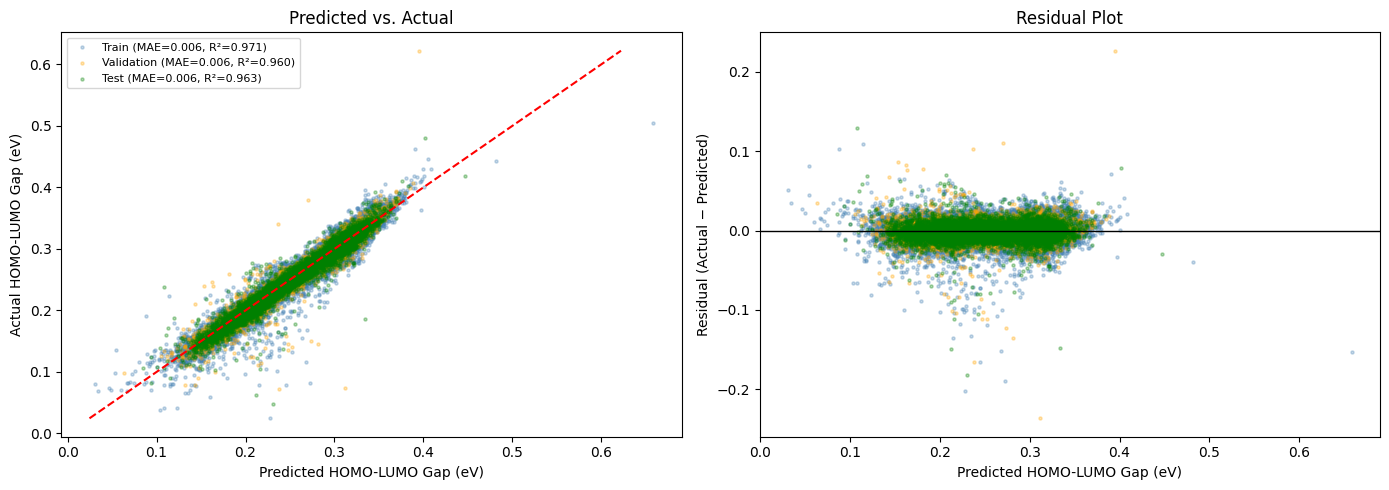

In [17]:
# Load the best checkpoint before evaluation
model_gcn.load_state_dict(torch.load("best_gcn.pt", map_location=device))

loaders = {"Train": train_loader, "Validation": val_loader, "Test": test_loader}
print_metrics(model_gcn, loaders)
plot_predictions(model_gcn, loaders)


## 10. Train GIN Model

In [18]:
model_gin = GIN(dim_input=DIM_INPUT, dim_hidden=128, dropout=0.3).to(device)
print(model_gin)
total_params = sum(p.numel() for p in model_gin.parameters())
print(f"\nTotal parameters: {total_params:,}")


GIN(
  (conv1): GINConv(nn=Sequential(
    (0): Linear(in_features=36, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
  ))
  (conv2): GINConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
  ))
  (conv3): GINConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
  ))
  (conv4): GINConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum

In [ ]:
gin_train_loss, gin_val_loss = train_model(
    model_gin, train_loader, val_loader,
    epochs=300, lr=1e-3,
    save_path="best_gin.pt"
)


Epoch    1/300 | Train MSE: 0.00011 | Val MSE: 0.00009 | LR: 1.00e-03
Epoch   20/300 | Train MSE: 0.00010 | Val MSE: 0.00008 | LR: 1.00e-03
Epoch   40/300 | Train MSE: 0.00010 | Val MSE: 0.00009 | LR: 1.00e-03
Epoch   60/300 | Train MSE: 0.00009 | Val MSE: 0.00009 | LR: 5.00e-04
Epoch   80/300 | Train MSE: 0.00009 | Val MSE: 0.00008 | LR: 5.00e-04
Epoch  100/300 | Train MSE: 0.00008 | Val MSE: 0.00008 | LR: 2.50e-04
Epoch  120/300 | Train MSE: 0.00008 | Val MSE: 0.00008 | LR: 2.50e-04
Epoch  140/300 | Train MSE: 0.00008 | Val MSE: 0.00008 | LR: 1.25e-04
Epoch  160/300 | Train MSE: 0.00007 | Val MSE: 0.00008 | LR: 6.25e-05
Epoch  180/300 | Train MSE: 0.00007 | Val MSE: 0.00008 | LR: 3.13e-05
Epoch  200/300 | Train MSE: 0.00007 | Val MSE: 0.00008 | LR: 1.56e-05
Epoch  220/300 | Train MSE: 0.00007 | Val MSE: 0.00008 | LR: 7.81e-06
Epoch  240/300 | Train MSE: 0.00007 | Val MSE: 0.00008 | LR: 3.91e-06


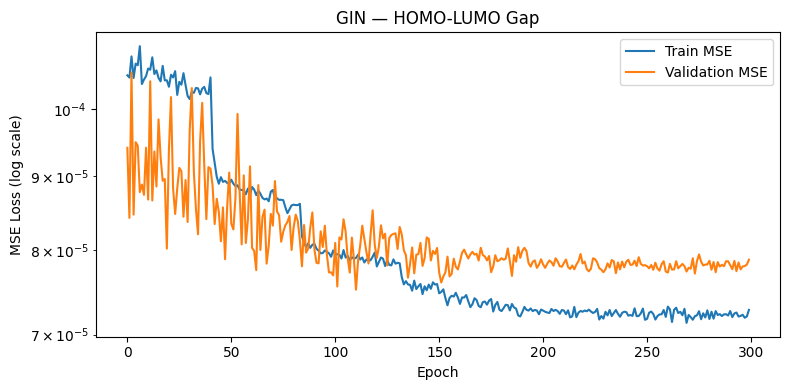

In [21]:
plot_loss_curves(gin_train_loss, gin_val_loss, title="GIN — HOMO-LUMO Gap")


Split          MAE (eV)   RMSE (eV)       R²
--------------------------------------------
Train            0.0037      0.0051   0.9884
Validation       0.0049      0.0087   0.9666
Test             0.0049      0.0079   0.9726


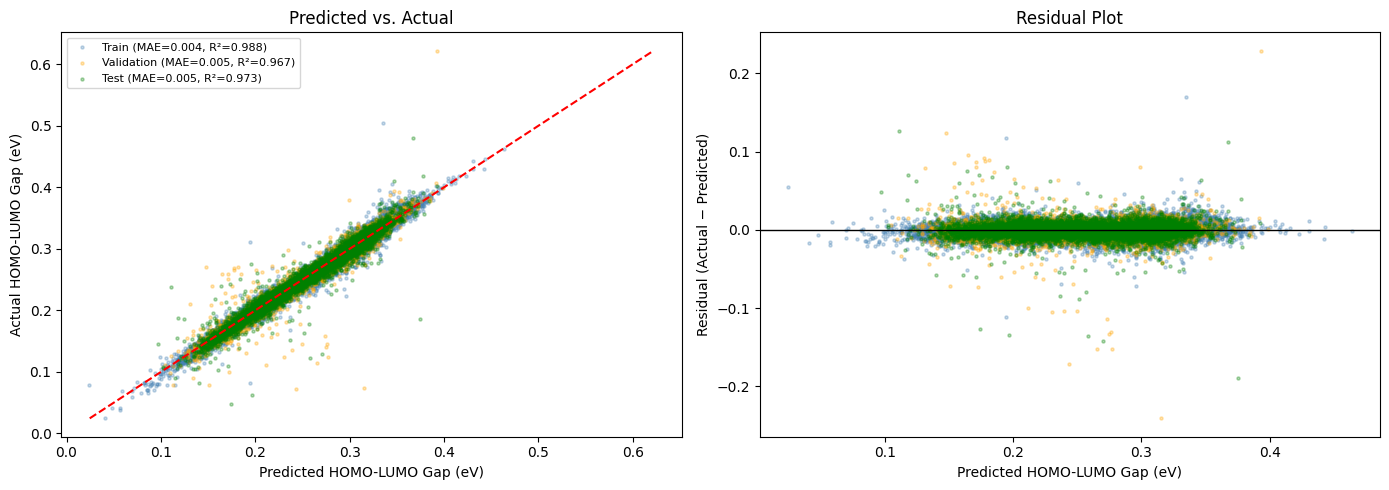

In [22]:
model_gin.load_state_dict(torch.load("best_gin.pt", map_location=device))

loaders = {"Train": train_loader, "Validation": val_loader, "Test": test_loader}
print_metrics(model_gin, loaders)
plot_predictions(model_gin, loaders)


## 11. Compare GCN vs. GIN

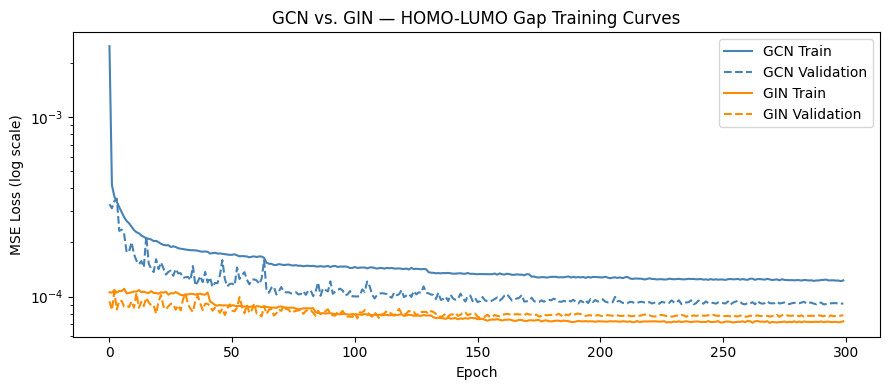

In [23]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(gcn_train_loss, label="GCN Train",      color="steelblue", ls="-")
ax.semilogy(gcn_val_loss,   label="GCN Validation", color="steelblue", ls="--")
ax.semilogy(gin_train_loss, label="GIN Train",      color="darkorange", ls="-")
ax.semilogy(gin_val_loss,   label="GIN Validation", color="darkorange", ls="--")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss (log scale)")
ax.set_title("GCN vs. GIN — HOMO-LUMO Gap Training Curves")
ax.legend(); plt.tight_layout(); plt.show()


In [24]:
print("=== GCN ===")
model_gcn.load_state_dict(torch.load("best_gcn.pt", map_location=device))
print_metrics(model_gcn, {"Train": train_loader, "Validation": val_loader, "Test": test_loader})

print("\n=== GIN ===")
model_gin.load_state_dict(torch.load("best_gin.pt", map_location=device))
print_metrics(model_gin, {"Train": train_loader, "Validation": val_loader, "Test": test_loader})


=== GCN ===
Split          MAE (eV)   RMSE (eV)       R²
--------------------------------------------
Train            0.0057      0.0081   0.9711
Validation       0.0061      0.0095   0.9599
Test             0.0061      0.0091   0.9630

=== GIN ===
Split          MAE (eV)   RMSE (eV)       R²
--------------------------------------------
Train            0.0037      0.0051   0.9884
Validation       0.0049      0.0087   0.9666
Test             0.0049      0.0079   0.9726


## 12. Save Training Statistics for Applicability Domain

We record the distribution of molecular descriptors from the **training set**
so the prediction notebook can flag out-of-domain molecules.


In [25]:
import json

def mol_descriptors(mol):
    """Compute simple scalar descriptors for applicability domain checks."""
    return {
        "mw":        Descriptors.MolWt(mol),
        "logp":      Descriptors.MolLogP(mol),
        "hbd":       rdMolDescriptors.CalcNumHBD(mol),
        "hba":       rdMolDescriptors.CalcNumHBA(mol),
        "rotbonds":  rdMolDescriptors.CalcNumRotatableBonds(mol),
        "rings":     rdMolDescriptors.CalcNumRings(mol),
        "num_atoms": mol.GetNumAtoms(),
        "num_heavy":  mol.GetNumHeavyAtoms(),
    }

# Compute descriptors for training SMILES
train_smiles = [df_use["smiles"].iloc[i] for i in range(train_end)]
desc_list = []
for smi in tqdm(train_smiles, desc="Computing applicability stats"):
    mol = Chem.MolFromSmiles(smi)
    if mol:
        desc_list.append(mol_descriptors(mol))

desc_df = pd.DataFrame(desc_list)
print(desc_df.describe())

# Save training domain statistics
domain_stats = {}
for col in desc_df.columns:
    domain_stats[col] = {
        "mean": float(desc_df[col].mean()),
        "std":  float(desc_df[col].std()),
        "min":  float(desc_df[col].min()),
        "max":  float(desc_df[col].max()),
        "q01":  float(desc_df[col].quantile(0.01)),
        "q99":  float(desc_df[col].quantile(0.99)),
    }

# Also save the set of elements seen in training
train_elements = set()
for smi in train_smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        for atom in mol.GetAtoms():
            train_elements.add(atom.GetSymbol())

domain_stats["_elements"] = sorted(list(train_elements))
domain_stats["_max_heavy_atoms"] = int(desc_df["num_heavy"].max())
domain_stats["_target"] = TARGET

with open("domain_stats.json", "w") as f:
    json.dump(domain_stats, f, indent=2)

print("\nSaved domain_stats.json")
print("Training elements:", domain_stats["_elements"])


Computing applicability stats:   0%|          | 0/107108 [00:00<?, ?it/s]

                  mw           logp            hbd            hba  \
count  107108.000000  107108.000000  107108.000000  107108.000000   
mean      121.741854       0.296559       0.799669       2.109124   
std         7.987046       1.001347       0.830014       0.975124   
min        16.043000      -4.909700       0.000000       0.000000   
25%       120.155000      -0.346400       0.000000       1.000000   
50%       124.143000       0.282200       1.000000       2.000000   
75%       126.199000       0.952700       1.000000       3.000000   
max       141.092000       3.612800       5.000000       6.000000   

            rotbonds          rings      num_atoms      num_heavy  
count  107108.000000  107108.000000  107108.000000  107108.000000  
mean        0.783732       1.825895       8.744828       8.744828  
std         1.023802       1.249360       0.557478       0.557478  
min         0.000000       0.000000       1.000000       1.000000  
25%         0.000000       1.000000   

## 13. Summary

| Model | Param | Train MAE | Val MAE | Test MAE | Test R² |
|-------|-------|-----------|---------|----------|---------|
| GCN   | ~100k | *see above* | *see above* | *see above* | *see above* |
| GIN   | ~200k | *see above* | *see above* | *see above* | *see above* |

Both models are saved to `best_gcn.pt` and `best_gin.pt`.  
Applicability domain statistics are saved to `domain_stats.json`.  
Use `Notebook_2_Prediction.ipynb` to predict the HOMO-LUMO gap for any new molecule given as a SMILES string.


In [26]:
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install rdkit torch_geometric

import json, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as Fun
from torch.nn import Linear, Sequential, BatchNorm1d, ReLU, Dropout
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GINConv, global_mean_pool, global_add_pool
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, rdMolDescriptors, rdDepictor
from rdkit.Chem.Draw import MolToImage

warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cpu


In [27]:
ATOM_FEATURES = {
    "atomic_num":    [1, 6, 7, 8, 9],
    "degree":        [0, 1, 2, 3, 4, 5],
    "formal_charge": [-1, 0, 1],
    "chiral_tag":    [0, 1, 2, 3],
    "hybridization": [
        Chem.rdchem.HybridizationType.S,
        Chem.rdchem.HybridizationType.SP,
        Chem.rdchem.HybridizationType.SP2,
        Chem.rdchem.HybridizationType.SP3,
        Chem.rdchem.HybridizationType.SP3D,
        Chem.rdchem.HybridizationType.SP3D2,
    ],
    "num_hs": [0, 1, 2, 3, 4],
}

BOND_FEATURES = {
    "bond_type": [
        Chem.rdchem.BondType.SINGLE,
        Chem.rdchem.BondType.DOUBLE,
        Chem.rdchem.BondType.TRIPLE,
        Chem.rdchem.BondType.AROMATIC,
    ],
    "stereo": [0, 1, 2, 3, 4, 5],
}


def one_hot(value, choices):
    encoding = [0] * (len(choices) + 1)
    idx = choices.index(value) if value in choices else len(choices)
    encoding[idx] = 1
    return encoding


def atom_features(atom):
    feats = []
    feats += one_hot(atom.GetAtomicNum(),        ATOM_FEATURES["atomic_num"])
    feats += one_hot(atom.GetDegree(),           ATOM_FEATURES["degree"])
    feats += one_hot(atom.GetFormalCharge(),     ATOM_FEATURES["formal_charge"])
    feats += one_hot(int(atom.GetChiralTag()),   ATOM_FEATURES["chiral_tag"])
    feats += one_hot(atom.GetHybridization(),    ATOM_FEATURES["hybridization"])
    feats += one_hot(atom.GetTotalNumHs(),       ATOM_FEATURES["num_hs"])
    feats.append(int(atom.GetIsAromatic()))
    return feats


def bond_features(bond):
    feats = []
    feats += one_hot(bond.GetBondType(),    BOND_FEATURES["bond_type"])
    feats += one_hot(int(bond.GetStereo()), BOND_FEATURES["stereo"])
    feats.append(int(bond.GetIsConjugated()))
    feats.append(int(bond.IsInRing()))
    return feats


def mol_to_graph(mol):
    if mol is None:
        return None
    x = torch.tensor([atom_features(a) for a in mol.GetAtoms()], dtype=torch.float)
    edge_index, edge_attr = [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        bf = bond_features(bond)
        edge_index += [[i, j], [j, i]]
        edge_attr  += [bf, bf]
    if len(edge_index) == 0:
        edge_index = torch.zeros((2, 0), dtype=torch.long)
        edge_attr  = torch.zeros((0, 14), dtype=torch.float)
    else:
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_attr  = torch.tensor(edge_attr,  dtype=torch.float)
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)


def smi_to_graph(smi):
    mol = Chem.MolFromSmiles(smi)
    return mol_to_graph(mol), mol

print("Feature functions ready.")


Feature functions ready.


In [28]:
class GCN(torch.nn.Module):
    def __init__(self, dim_input, dim_hidden=128, dropout=0.3):
        super().__init__()
        self.conv1 = GCNConv(dim_input,  dim_hidden)
        self.conv2 = GCNConv(dim_hidden, dim_hidden)
        self.conv3 = GCNConv(dim_hidden, dim_hidden)
        self.bn1   = BatchNorm1d(dim_hidden)
        self.bn2   = BatchNorm1d(dim_hidden)
        self.bn3   = BatchNorm1d(dim_hidden)
        self.lin1  = Linear(dim_hidden, dim_hidden // 2)
        self.lin2  = Linear(dim_hidden // 2, 1)
        self.drop  = Dropout(p=dropout)

    def forward(self, data):
        x, e, batch = data.x, data.edge_index, data.batch
        x = self.bn1(self.conv1(x, e).relu())
        x = self.bn2(self.conv2(x, e).relu())
        x = self.bn3(self.conv3(x, e).relu())
        x = global_mean_pool(x, batch)
        x = self.drop(x)
        x = self.lin1(x).relu()
        x = self.drop(x)
        return self.lin2(x)


class GIN(torch.nn.Module):
    def _mlp(self, in_dim, out_dim):
        return Sequential(
            Linear(in_dim, out_dim), BatchNorm1d(out_dim), ReLU(),
            Linear(out_dim, out_dim), ReLU()
        )

    def __init__(self, dim_input, dim_hidden=128, dropout=0.3):
        super().__init__()
        self.conv1 = GINConv(self._mlp(dim_input,  dim_hidden))
        self.conv2 = GINConv(self._mlp(dim_hidden, dim_hidden))
        self.conv3 = GINConv(self._mlp(dim_hidden, dim_hidden))
        self.conv4 = GINConv(self._mlp(dim_hidden, dim_hidden))
        self.lin1  = Linear(dim_hidden, dim_hidden)
        self.lin2  = Linear(dim_hidden, dim_hidden // 2)
        self.lin3  = Linear(dim_hidden // 2, 1)
        self.drop  = Dropout(p=dropout)

    def forward(self, data):
        x, e, batch = data.x, data.edge_index, data.batch
        x = self.conv1(x, e).relu()
        x = self.conv2(x, e).relu()
        x = self.conv3(x, e).relu()
        x = self.conv4(x, e)
        x = global_add_pool(x, batch)
        x = self.lin1(x).relu()
        x = self.drop(x)
        x = self.lin2(x).relu()
        x = self.drop(x)
        return self.lin3(x)

print("Model classes defined.")


Model classes defined.


In [29]:
# ── Load applicability domain statistics ──────────────────────────────────
DOMAIN_FILE = "domain_stats.json"
assert os.path.exists(DOMAIN_FILE), (
    f"'{DOMAIN_FILE}' not found. Please run Notebook_1_Training_HOMO_LUMO.ipynb first."
)
with open(DOMAIN_FILE) as f:
    domain_stats = json.load(f)

TARGET       = domain_stats["_target"]
TRAIN_ELEMS  = set(domain_stats["_elements"])
MAX_HEAVY    = domain_stats["_max_heavy_atoms"]

print(f"Target property : {TARGET}  (HOMO-LUMO gap, eV)")
print(f"Training elements : {sorted(TRAIN_ELEMS)}")
print(f"Max heavy atoms in training : {MAX_HEAVY}")

# ── Compute node feature dimension ────────────────────────────────────────
_test_mol = Chem.MolFromSmiles("CCO")
_test_g   = mol_to_graph(_test_mol)
DIM_INPUT = _test_g.num_features
print(f"Node feature dim  : {DIM_INPUT}")

# ── Load the best model (prefer GIN) ──────────────────────────────────────
MODEL_FILE = "best_gin.pt"
if not os.path.exists(MODEL_FILE):
    MODEL_FILE = "best_gcn.pt"
    ModelClass = GCN
else:
    ModelClass = GIN

assert os.path.exists(MODEL_FILE), (
    "No trained model found (best_gin.pt / best_gcn.pt). "
    "Run Notebook_1_Training_HOMO_LUMO.ipynb first."
)

model = ModelClass(dim_input=DIM_INPUT, dim_hidden=128, dropout=0.0).to(device)
model.load_state_dict(torch.load(MODEL_FILE, map_location=device))
model.eval()

print(f"\nLoaded model : {ModelClass.__name__}  from  '{MODEL_FILE}'")


Target property : gap  (HOMO-LUMO gap, eV)
Training elements : ['C', 'F', 'N', 'O']
Max heavy atoms in training : 9
Node feature dim  : 36

Loaded model : GIN  from  'best_gin.pt'


In [30]:
def mol_descriptors(mol):
    return {
        "mw":        Descriptors.MolWt(mol),
        "logp":      Descriptors.MolLogP(mol),
        "hbd":       rdMolDescriptors.CalcNumHBD(mol),
        "hba":       rdMolDescriptors.CalcNumHBA(mol),
        "rotbonds":  rdMolDescriptors.CalcNumRotatableBonds(mol),
        "rings":     rdMolDescriptors.CalcNumRings(mol),
        "num_atoms": mol.GetNumAtoms(),
        "num_heavy":  mol.GetNumHeavyAtoms(),
    }


def check_applicability(smi):
    """
    Validate a SMILES string and check if it falls within the model's
    applicability domain.

    Returns
    -------
    mol       : RDKit Mol object (or None if invalid)
    passed    : bool — True if all hard checks pass
    warnings  : list of warning strings (soft violations)
    errors    : list of error strings (hard violations — prediction blocked)
    """
    errors   = []
    warnings = []

    # ── Hard check 1: valid SMILES ────────────────────────────────────────
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        errors.append("INVALID SMILES — RDKit cannot parse this string.")
        return None, False, warnings, errors

    try:
        Chem.SanitizeMol(mol)
    except Exception as e:
        errors.append(f"Sanitization failed: {e}")
        return None, False, warnings, errors

    # ── Hard check 2: element coverage ───────────────────────────────────
    mol_elems = {atom.GetSymbol() for atom in mol.GetAtoms()}
    unknown   = mol_elems - TRAIN_ELEMS
    if unknown:
        errors.append(
            f"Element(s) {unknown} not in training set {sorted(TRAIN_ELEMS)}. "
            "Prediction would be unreliable — blocked."
        )
        return mol, False, warnings, errors

    # ── Hard check 3: size limit ──────────────────────────────────────────
    n_heavy = mol.GetNumHeavyAtoms()
    if n_heavy > MAX_HEAVY:
        errors.append(
            f"Molecule has {n_heavy} heavy atoms, exceeding the training max of "
            f"{MAX_HEAVY}. Prediction blocked."
        )
        return mol, False, warnings, errors

    # ── Soft checks: descriptor ranges (1st–99th percentile) ─────────────
    desc = mol_descriptors(mol)
    for key, val in desc.items():
        if key not in domain_stats:
            continue
        stats = domain_stats[key]
        if val < stats["q01"] or val > stats["q99"]:
            warnings.append(
                f"  ⚠  {key} = {val:.2f}  is outside training 1–99th pct "
                f"[{stats['q01']:.2f}, {stats['q99']:.2f}]"
            )

    passed = len(errors) == 0
    return mol, passed, warnings, errors


In [31]:
@torch.no_grad()
def predict_homo_lumo_gap(smi, show_structure=True, verbose=True):
    """
    Predict the HOMO-LUMO gap (eV) for a molecule given as a SMILES string.

    Parameters
    ----------
    smi            : str — SMILES string
    show_structure : bool — display 2D structure
    verbose        : bool — print full applicability report

    Returns
    -------
    gap_eV : float or None
    """
    print(f"{'='*60}")
    print(f"SMILES  : {smi}")
    print(f"{'='*60}")

    # ── 1. Applicability domain check ─────────────────────────────────────
    mol, passed, warnings, errors = check_applicability(smi)

    if errors:
        print("\n❌  HARD ERRORS — prediction blocked:")
        for e in errors: print(f"  {e}")
        return None

    if warnings and verbose:
        print("\n⚠   Out-of-domain warnings (prediction may be less reliable):")
        for w in warnings: print(w)
    elif not warnings:
        print("\n✅  Applicability domain: PASS — molecule is within training domain.")

    # ── 2. Show 2D structure ──────────────────────────────────────────────
    if show_structure and mol is not None:
        rdDepictor.Compute2DCoords(mol)
        img = MolToImage(mol, size=(300, 300))
        display(img)

    # ── 3. Convert to graph & predict ─────────────────────────────────────
    graph = mol_to_graph(mol)
    if graph is None:
        print("Failed to build molecular graph.")
        return None

    # Add a batch index of 0 (single molecule)
    graph.batch = torch.zeros(graph.x.shape[0], dtype=torch.long)
    graph = graph.to(device)
    graph.x = graph.x.float()

    pred = model(graph).item()

    # ── 4. Report ─────────────────────────────────────────────────────────
    print(f"\n{'─'*40}")
    desc = mol_descriptors(mol)
    print(f"  Heavy atoms  : {desc['num_heavy']}")
    print(f"  MW           : {desc['mw']:.2f} g/mol")
    print(f"  logP         : {desc['logp']:.2f}")
    print(f"  HBD / HBA    : {desc['hbd']} / {desc['hba']}")
    print(f"{'─'*40}")
    print(f"  🔬  Predicted HOMO-LUMO gap : {pred:.4f} eV")
    print(f"{'─'*40}\n")

    return pred


In [32]:
# ── Batch predictions on a list of molecules ──────────────────────────────
SMILES_TO_TEST = [
    ("Methane",         "C"),
    ("Ethanol",         "CCO"),
    ("Benzene",         "c1ccccc1"),
    ("Caffeine",        "Cn1cnc2c1c(=O)n(c(=O)n2C)C"),
    ("Naphthalene",     "c1ccc2ccccc2c1"),
    ("Aniline",         "Nc1ccccc1"),
    ("Furan",           "c1ccoc1"),
    ("Adenine",         "Nc1ncnc2[nH]cnc12"),
    # Out-of-domain examples (will trigger warnings or errors):
    ("Chlorobenzene",   "Clc1ccccc1"),   # Cl not in QM9
    ("Invalid SMILES",  "XYZ!!!"),
]

results = {}
for name, smi in SMILES_TO_TEST:
    print(f"\n>>> {name}")
    gap = predict_homo_lumo_gap(smi, show_structure=False, verbose=False)
    if gap is not None:
        results[name] = gap



>>> Methane
SMILES  : C

────────────────────────────────────────
  Heavy atoms  : 1
  MW           : 16.04 g/mol
  logP         : 0.64
  HBD / HBA    : 0 / 0
────────────────────────────────────────
  🔬  Predicted HOMO-LUMO gap : 0.3351 eV
────────────────────────────────────────


>>> Ethanol
SMILES  : CCO

────────────────────────────────────────
  Heavy atoms  : 3
  MW           : 46.07 g/mol
  logP         : -0.00
  HBD / HBA    : 1 / 1
────────────────────────────────────────
  🔬  Predicted HOMO-LUMO gap : 0.3357 eV
────────────────────────────────────────


>>> Benzene
SMILES  : c1ccccc1

────────────────────────────────────────
  Heavy atoms  : 6
  MW           : 78.11 g/mol
  logP         : 1.69
  HBD / HBA    : 0 / 0
────────────────────────────────────────
  🔬  Predicted HOMO-LUMO gap : 0.2465 eV
────────────────────────────────────────


>>> Caffeine
SMILES  : Cn1cnc2c1c(=O)n(c(=O)n2C)C

❌  HARD ERRORS — prediction blocked:
  Molecule has 14 heavy atoms, exceeding the trai

[04:20:58] SMILES Parse Error: syntax error while parsing: XYZ!!!
[04:20:58] SMILES Parse Error: check for mistakes around position 1:
[04:20:58] XYZ!!!
[04:20:58] ^
[04:20:58] SMILES Parse Error: Failed parsing SMILES 'XYZ!!!' for input: 'XYZ!!!'


In [33]:
# ── Summary table ─────────────────────────────────────────────────────────
if results:
    print(f"\n{'Molecule':<20} {'HOMO-LUMO Gap (eV)':>20}")
    print("-" * 42)
    for name, gap in results.items():
        print(f"{name:<20} {gap:>20.4f}")



Molecule               HOMO-LUMO Gap (eV)
------------------------------------------
Methane                            0.3351
Ethanol                            0.3357
Benzene                            0.2465
Aniline                            0.2027
Furan                              0.2448


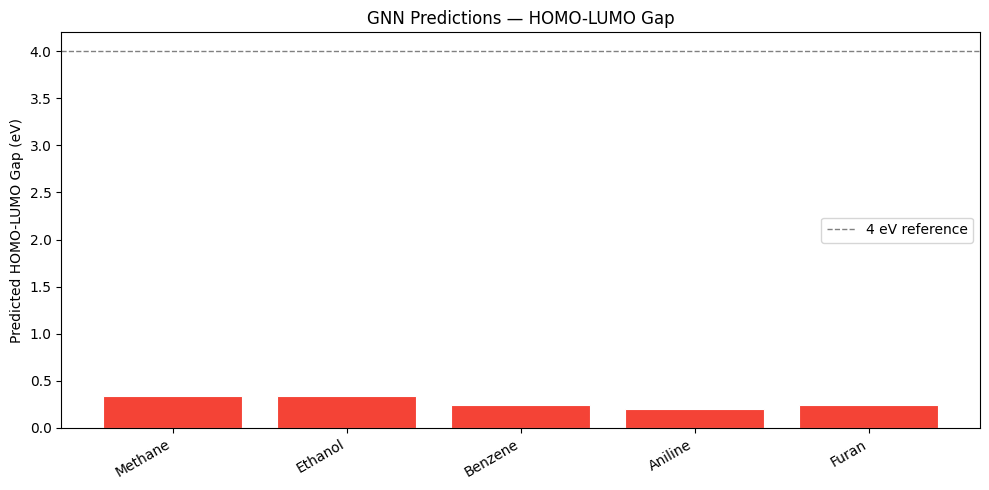

In [34]:
# ── Bar chart of predictions ──────────────────────────────────────────────
if results:
    names = list(results.keys())
    gaps  = list(results.values())
    colors = ['#2196F3' if g > 4 else '#FF9800' if g > 2 else '#F44336' for g in gaps]

    plt.figure(figsize=(10, 5))
    bars = plt.bar(names, gaps, color=colors, edgecolor='white', linewidth=0.8)
    plt.axhline(y=4.0, color='gray', ls='--', lw=1, label='4 eV reference')
    plt.xticks(rotation=30, ha='right')
    plt.ylabel("Predicted HOMO-LUMO Gap (eV)")
    plt.title("GNN Predictions — HOMO-LUMO Gap")
    plt.legend()
    plt.tight_layout()
    plt.show()


SMILES  : c1ccc(cc1)C=O

✅  Applicability domain: PASS — molecule is within training domain.


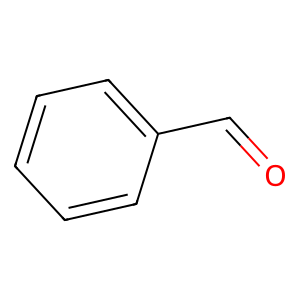


────────────────────────────────────────
  Heavy atoms  : 8
  MW           : 106.12 g/mol
  logP         : 1.50
  HBD / HBA    : 0 / 1
────────────────────────────────────────
  🔬  Predicted HOMO-LUMO gap : 0.1897 eV
────────────────────────────────────────



In [35]:
# ── Edit this cell to predict for your own molecule ───────────────────────

MY_SMILES = "c1ccc(cc1)C=O"   # <── change this to any SMILES string

gap = predict_homo_lumo_gap(MY_SMILES, show_structure=True, verbose=True)
